# MNIST Handwritten Digits Recognition – Machine Learning Project

This project builds Machine Learning and Deep Learning models to recognize handwritten digits using the MNIST dataset.

In [22]:
%pip install tensorflow

import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D # type: ignore
from tensorflow.keras.utils import to_categorical # type: ignore
from tensorflow.keras.datasets import mnist # type: ignore
from sklearn.metrics import classification_report, confusion_matrix

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## Load Dataset

In [23]:

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training Data Shape:", x_train.shape)
print("Testing Data Shape:", x_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)


## Visualize Sample Images

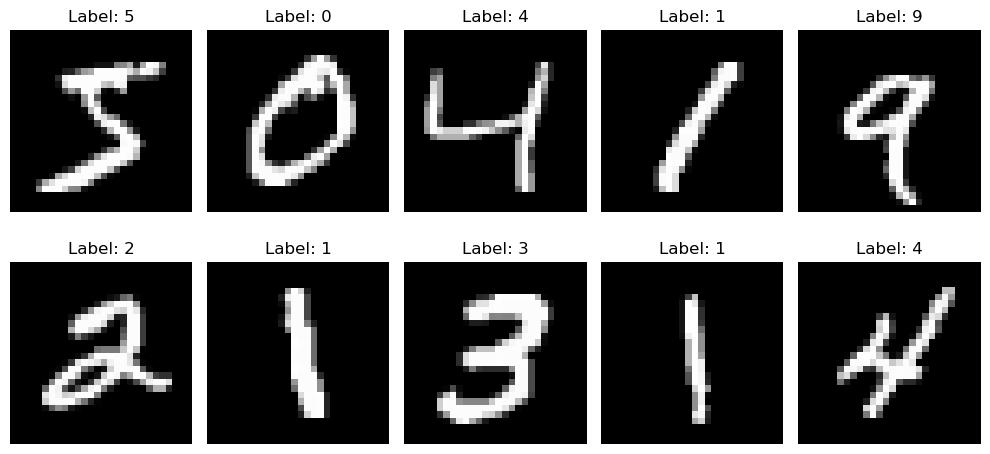

In [24]:

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()


## Data Preprocessing

In [25]:

# Normalize pixel values
x_train = x_train / 255.0
x_test = x_test / 255.0

# Convert labels into categorical format
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Preprocessing completed")


Preprocessing completed


## Build ANN Model

In [26]:

model = Sequential()

model.add(Flatten(input_shape=(28,28)))

model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))

model.add(Dense(10, activation='softmax'))

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## Compile ANN Model

In [27]:

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


## Train ANN Model

In [28]:

history = model.fit(
    x_train,
    y_train_cat,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9186 - loss: 0.2773 - val_accuracy: 0.9578 - val_loss: 0.1424
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9638 - loss: 0.1193 - val_accuracy: 0.9622 - val_loss: 0.1183
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9751 - loss: 0.0816 - val_accuracy: 0.9703 - val_loss: 0.0976
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9812 - loss: 0.0592 - val_accuracy: 0.9736 - val_loss: 0.0891
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9861 - loss: 0.0450 - val_accuracy: 0.9745 - val_loss: 0.0862
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9877 - loss: 0.0383 - val_accuracy: 0.9720 - val_loss: 0.1004
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9905 - loss: 0.0293 - val_accuracy: 0.9714 - val_loss: 0.1011
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9914 - loss: 0.0260 - 

## Evaluate ANN Model

In [29]:

loss, accuracy = model.evaluate(x_test, y_test_cat)

print("Test Accuracy:", accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9768 - loss: 0.0990
Test Accuracy: 0.9768000245094299


## Make Predictions

In [30]:

predictions = model.predict(x_test)

predicted_labels = np.argmax(predictions, axis=1)

print(predicted_labels[:10])


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 985us/step
[7 2 1 0 4 1 4 9 5 9]


## Classification Report

In [31]:

print(classification_report(y_test, predicted_labels))


              precision    recall  f1-score   support

           0       0.99      0.98      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.99      0.97      1032
           3       0.97      0.97      0.97      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.98      0.98       892
           6       0.97      0.99      0.98       958
           7       0.96      0.97      0.97      1028
           8       0.98      0.97      0.97       974
           9       0.98      0.95      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



## Confusion Matrix

In [32]:

cm = confusion_matrix(y_test, predicted_labels)

print(cm)


[[ 962    1    4    1    0    3    7    1    1    0]
 [   0 1125    3    1    0    1    3    1    1    0]
 [   1    1 1020    0    1    0    1    4    4    0]
 [   0    0    7  983    0    4    0    7    6    3]
 [   0    0    8    1  960    0    3    4    2    4]
 [   2    0    0    8    1  871    7    1    2    0]
 [   2    1    1    1    2    2  948    0    1    0]
 [   1    4   14    5    1    0    0  998    1    4]
 [   0    1    8    2    1    5    7    6  940    4]
 [   0    3    3    7   10    2    2   18    3  961]]


## Display Prediction Results

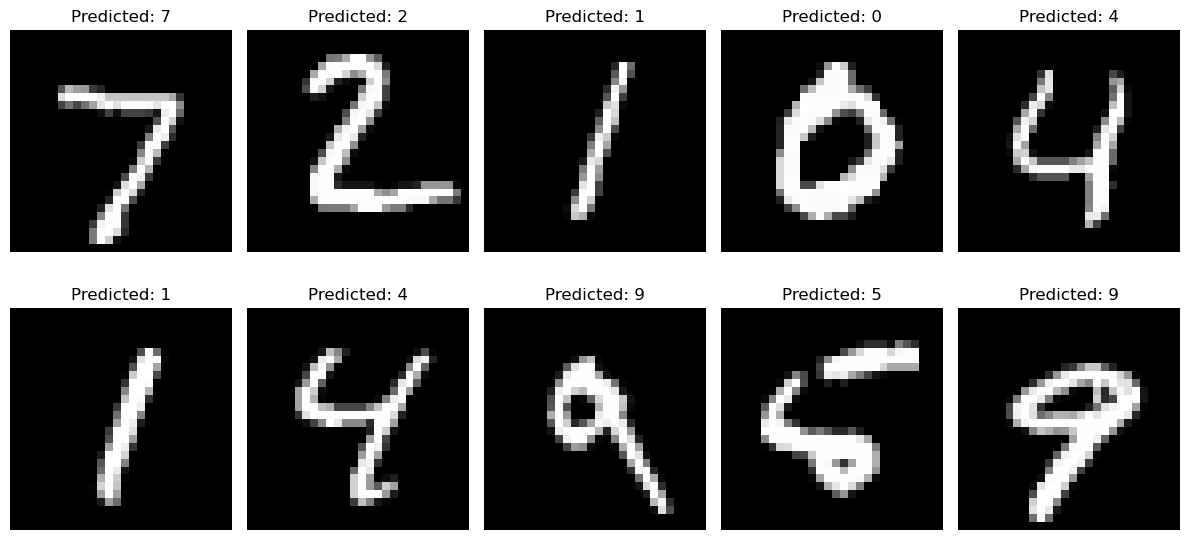

In [33]:

plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"Predicted: {predicted_labels[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()


## Save ANN Model

In [34]:

model.save('handwritten_digit_model.h5')

print("ANN Model saved successfully")


ANN Model saved successfully


# Advanced CNN Model

## Reshape Data for CNN

In [35]:

x_train_cnn = x_train.reshape(-1,28,28,1)
x_test_cnn = x_test.reshape(-1,28,28,1)

print(x_train_cnn.shape)


(60000, 28, 28, 1)


## Build CNN Model

In [36]:

cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

cnn_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## Compile CNN Model

In [37]:

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


## Train CNN Model

In [38]:

cnn_history = cnn_model.fit(
    x_train_cnn,
    y_train_cat,
    epochs=5,
    validation_split=0.2
)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9535 - loss: 0.1519 - val_accuracy: 0.9827 - val_loss: 0.0596
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9845 - loss: 0.0488 - val_accuracy: 0.9864 - val_loss: 0.0453
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9897 - loss: 0.0333 - val_accuracy: 0.9874 - val_loss: 0.0410
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9920 - loss: 0.0247 - val_accuracy: 0.9882 - val_loss: 0.0409
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9944 - loss: 0.0174 - val_accuracy: 0.9922 - val_loss: 0.0352


## Evaluate CNN Model

In [39]:

cnn_loss, cnn_accuracy = cnn_model.evaluate(
    x_test_cnn,
    y_test_cat
)

print("CNN Accuracy:", cnn_accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9926 - loss: 0.0261
CNN Accuracy: 0.9926000237464905


## Save CNN Model

In [40]:

cnn_model.save('cnn_handwritten_digit_model.h5')

print("CNN Model saved successfully")


CNN Model saved successfully


# Project Conclusion


- ANN model achieves approximately 97%–98% accuracy.
- CNN model achieves approximately 98%–99% accuracy.
- CNN performs better because it captures image features more effectively.
